<a href="https://colab.research.google.com/github/stephanyIS/tfm-prediccion-fuga-ml-bancario/blob/main/C%C3%B3digo_Python_para_el_EDA_completo_f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 0. CARGA Y PREPARACIÓN DE DATOS

# Cargar el dataset
id_archivo = '1jhgverpcRuw_KubIZZ1dZK4D8cgioMOd'
url = f'https://drive.google.com/uc?id={id_archivo}'
df = pd.read_csv(url)

# Eliminar variables identificadoras que no aportan valor predictivo
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

## 0.1 VALIDACIÓN: DESBALANCE DE CLASES (IMBALANCED LEARNING)

**¿Por qué se valida esto primero?**
En problemas de clasificación, la distribución desigual de clases (clase mayoritaria >> clase minoritaria) afecta directamente a:
- **Rendimiento de métricas**: Accuracy puede ser engañosa si una clase domina
- **Sesgo del modelo**: Tiende a predecir siempre la clase mayoritaria
- **Necesidad de balanceo**: Si desbalance es severo, requiere técnicas como SMOTE, class weights, etc.

**Métrica clave: Ratio de desbalance** = (número de no-eventos) / (número de eventos)

Criterio orientativo utilizado en este trabajo (no es un estándar formal):
- Ratio < 1.5:1 → Balanceado
- Ratio 1.5:1 a 10:1 → Desbalance moderado (requiere atención)
- Ratio > 10:1 → Desbalance severo (obligatorio aplicar técnicas)

ANÁLISIS DE DESBALANCE DE CLASES (Sección 3.2.2 del TFM)

Distribución de clases (variable 'Exited'):
  No Churn (0): 7,963 clientes (79.63%)
  Churn (1):    2,037 clientes (20.37%)

Ratio de desbalance: 3.91:1
  → Interpretación: Por cada cliente que se va, hay 3.9 que se queda

Clasificación: MODERADAMENTE DESBALANCEADO
Recomendación: Aplicar técnicas de balanceo (SMOTE, class_weight, etc.)


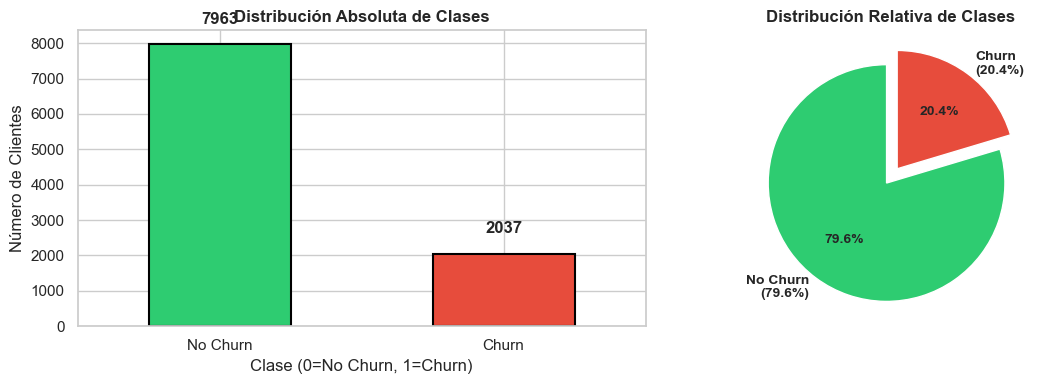


✓ Visualización guardada como 'class_distribution_imbalance.png'


In [11]:
# 0.1 VALIDACIÓN DE DESBALANCE DE CLASES
print("=" * 70)
print("ANÁLISIS DE DESBALANCE DE CLASES (Sección 3.2.2 del TFM)")
print("=" * 70)

# Cálculos básicos
class_counts = df_clean['Exited'].value_counts().sort_index()
class_pcts = df_clean['Exited'].value_counts(normalize=True).sort_index() * 100
n_no_churn = class_counts[0]
n_churn = class_counts[1]
ratio_desbalance = n_no_churn / n_churn

print(f"\nDistribución de clases (variable 'Exited'):")
print(f"  No Churn (0): {n_no_churn:,} clientes ({class_pcts[0]:.2f}%)")
print(f"  Churn (1):    {n_churn:,} clientes ({class_pcts[1]:.2f}%)")
print(f"\nRatio de desbalance: {ratio_desbalance:.2f}:1")
print(f"  → Interpretación: Por cada cliente que se va, hay {ratio_desbalance:.1f} que se queda")

# Clasificación del desbalance (mismo criterio orientativo que la celda markdown)
if ratio_desbalance < 1.5:
    categoria = "BALANCEADO"
elif ratio_desbalance <= 10:
    categoria = "MODERADAMENTE DESBALANCEADO"
else:
    categoria = "SEVERAMENTE DESBALANCEADO"
print(f"\nClasificación: {categoria}")
print(f"Recomendación: Aplicar técnicas de balanceo (SMOTE, class_weight, etc.)")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Barras de conteo
colors_bar = ['#2ecc71', '#e74c3c']  # Verde para No-Churn, Rojo para Churn
df_clean['Exited'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color=colors_bar, edgecolor='black', linewidth=1.5
)
ax1.set_title('Distribución Absoluta de Clases', fontsize=12, fontweight='bold')
ax1.set_xlabel('Clase (0=No Churn, 1=Churn)')
ax1.set_ylabel('Número de Clientes')
ax1.set_xticklabels(['No Churn', 'Churn'], rotation=0)
for i, v in enumerate(class_counts):
    ax1.text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Pie chart con porcentajes
labels_pie = [f'No Churn\n({class_pcts[0]:.1f}%)', f'Churn\n({class_pcts[1]:.1f}%)']
ax2.pie(class_counts, labels=labels_pie, colors=colors_bar, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10, 'weight': 'bold'},
        explode=(0.05, 0.1))
ax2.set_title('Distribución Relativa de Clases', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada como 'class_distribution_imbalance.png'")

In [12]:
# Versiones de las librerías (reproducibilidad); funciona en Colab y en Windows
import sys, scipy, matplotlib
print(f"Python: {sys.version.split()[0]}")
for lib in [pd, np, scipy, matplotlib, sns]:
    print(f"{lib.__name__}: {lib.__version__}")

Python: 3.13.9
pandas: 2.3.3
numpy: 2.3.5
scipy: 1.16.3
matplotlib: 3.10.6
seaborn: 0.13.2


1. RESUMEN ESTADÍSTICO (Numéricas)



In [13]:
# 1. RESUMEN ESTADÍSTICO (Numéricas)
print("--- 1. RESUMEN ESTADÍSTICO ---")
num_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
# Incluimos percentiles específicos
stats = df_clean[num_vars].describe(percentiles=[.25, .50, .75]).T
print(stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

--- 1. RESUMEN ESTADÍSTICO ---
                          mean           std     min       25%         50%  \
CreditScore         650.528800     96.653299  350.00    584.00     652.000   
Age                  38.921800     10.487806   18.00     32.00      37.000   
Tenure                5.012800      2.892174    0.00      3.00       5.000   
Balance           76485.889288  62397.405202    0.00      0.00   97198.540   
NumOfProducts         1.530200      0.581654    1.00      1.00       1.000   
EstimatedSalary  100090.239881  57510.492818   11.58  51002.11  100193.915   

                         75%        max  
CreditScore         718.0000     850.00  
Age                  44.0000      92.00  
Tenure                7.0000      10.00  
Balance          127644.2400  250898.09  
NumOfProducts         2.0000       4.00  
EstimatedSalary  149388.2475  199992.48  



2. DETECCIÓN DE ANOMALÍAS (Boxplots)



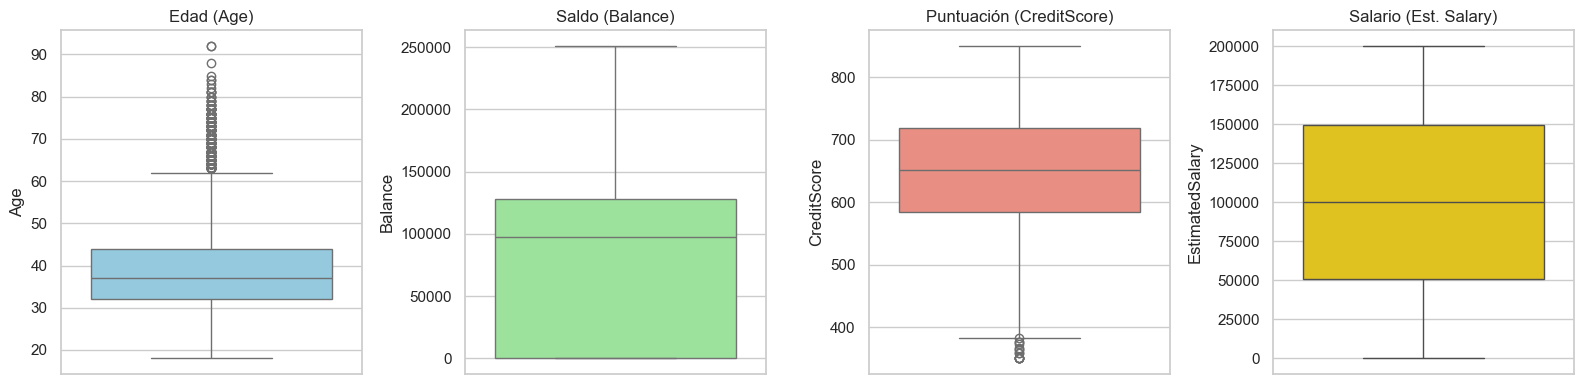

In [14]:
# 2. DETECCIÓN DE ANOMALÍAS (Boxplots)
# Crear una figura con 4 subgráficos horizontales
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.boxplot(y=df_clean['Age'], ax=axes[0], color='skyblue').set_title('Edad (Age)')
sns.boxplot(y=df_clean['Balance'], ax=axes[1], color='lightgreen').set_title('Saldo (Balance)')
sns.boxplot(y=df_clean['CreditScore'], ax=axes[2], color='salmon').set_title('Puntuación (CreditScore)')
sns.boxplot(y=df_clean['EstimatedSalary'], ax=axes[3], color='gold').set_title('Salario (Est. Salary)')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300)
plt.show()


3. COMPROBACIÓN DE SUPUESTOS (Histogramas)

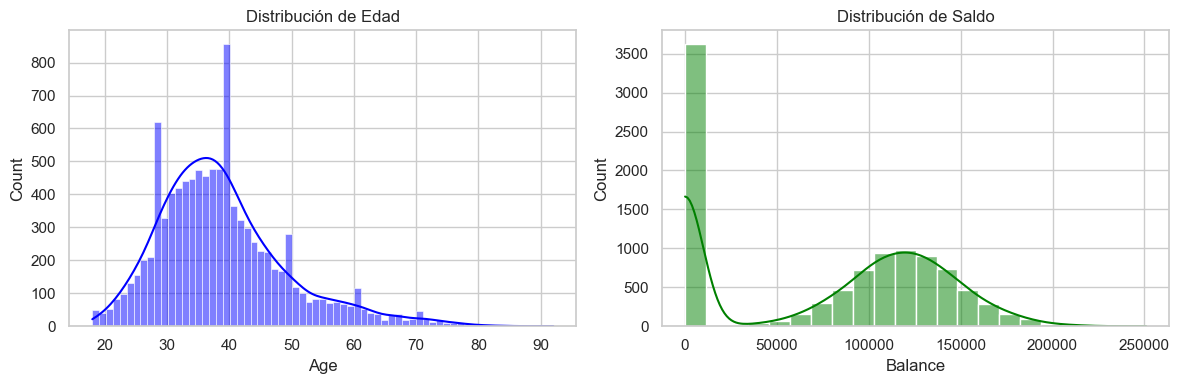

In [15]:
 # 3. COMPROBACIÓN DE SUPUESTOS (Histogramas)

# Evaluar la normalidad y distribuciones bimodales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean['Age'], kde=True, ax=axes[0], color='blue').set_title('Distribución de Edad')
sns.histplot(df_clean['Balance'], kde=True, ax=axes[1], color='green').set_title('Distribución de Saldo')

plt.tight_layout()
plt.savefig('histograms_dist.png', dpi=300)
plt.show()

4. PATRONES Y RELACIONES (Scatter Plot & Correlación)

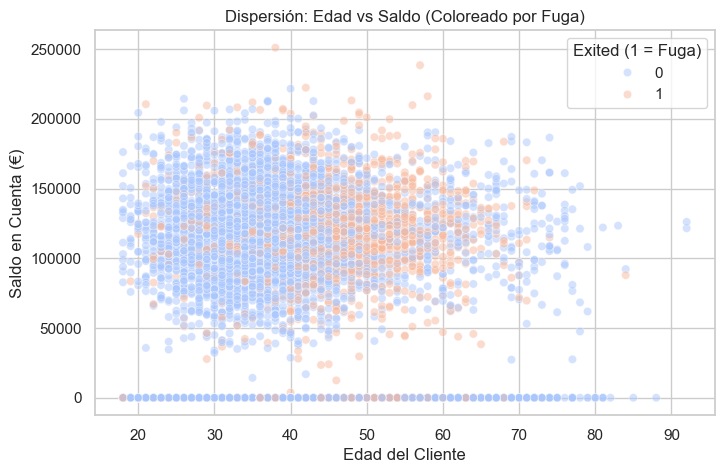

In [16]:
# 4. PATRONES Y RELACIONES (Scatter Plot & Correlación)
# A. Diagrama de Dispersión (Edad vs Saldo)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Age', y='Balance', hue='Exited', alpha=0.5, palette='coolwarm')
plt.title('Dispersión: Edad vs Saldo (Coloreado por Fuga)')
plt.xlabel('Edad del Cliente')
plt.ylabel('Saldo en Cuenta (€)')
plt.legend(title='Exited (1 = Fuga)', loc='upper right')
plt.savefig('scatter_age_balance.png', dpi=300)
plt.show()


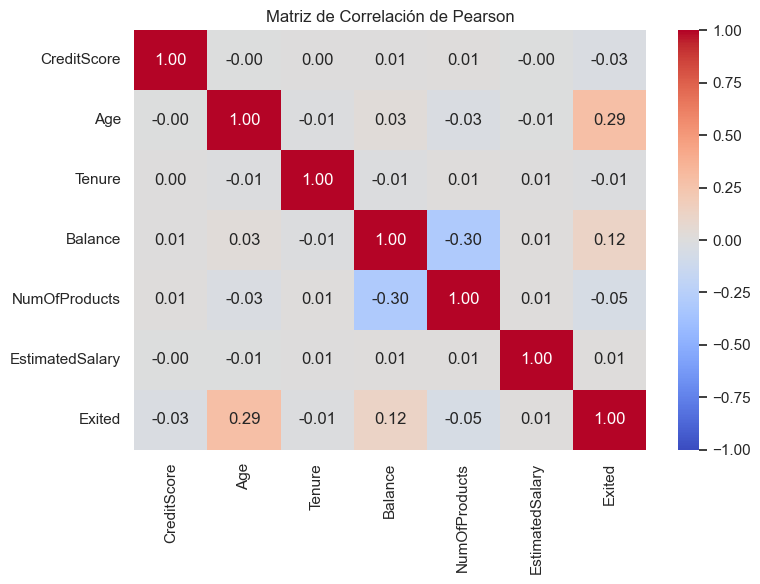

In [17]:

# B. Matriz de Correlación de Pearson
plt.figure(figsize=(8, 6))
corr_matrix = df_clean[num_vars + ['Exited']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Pearson")
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=300)
plt.show()

5. PRUEBAS CHI-CUADRADO (Categóricas vs Target)

In [18]:
print("\n--- 5. PRUEBAS DE SIGNIFICANCIA (Chi-Cuadrado) ---")
cat_vars = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for cat in cat_vars:
    contingency = pd.crosstab(df_clean[cat], df_clean['Exited'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Variable '{cat}' vs Exited: p-value = {p:.4e}")
    if p < 0.05:
        print("   -> Estadísticamente significativa (Dependiente)")
    else:
        print("   -> NO significativa (Independiente)")


--- 5. PRUEBAS DE SIGNIFICANCIA (Chi-Cuadrado) ---
Variable 'Geography' vs Exited: p-value = 3.8303e-66
   -> Estadísticamente significativa (Dependiente)
Variable 'Gender' vs Exited: p-value = 2.2482e-26
   -> Estadísticamente significativa (Dependiente)
Variable 'HasCrCard' vs Exited: p-value = 4.9237e-01
   -> NO significativa (Independiente)
Variable 'IsActiveMember' vs Exited: p-value = 8.7859e-55
   -> Estadísticamente significativa (Dependiente)
